Causal inference workflow for revealing individual and copuled causal effect on alloy strength

This script implements a physics-informed framwork to construct a structural caual model linking 
processing, composition, and microstructure to mechanical properties. 

Workflow:
1. Load experimental dataset and define variable groups (processing, composition, microstructure, property).
2. Establish physics-informed strengthening models using symbolic regression to model individual strengthening mechanisms.
3. Establish structural causal model using Bayesin Additive Regression Trees (BART) .
4. Perform causal inference to reveal individual causaleffects and causal interactions among strengthening mechanisms.



Author: Quan Li; quan.li@mpi-susmat.de

In [1]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from pysr import PySRRegressor, TemplateExpressionSpec
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from stochtree import BARTModel
from sklearn.model_selection import train_test_split
from pathlib import Path
from scipy.ndimage import gaussian_filter


# ============================================================
# 0. User settings
# ============================================================
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    PROJECT_ROOT = Path.cwd()

FILE_PATH = PROJECT_ROOT / "data" / "Dataset_PtAu.xlsx"
SHEET_NAME = "Anneal_Punch"

SAVE_RESULTS = True
OUTPUT_ROOT = PROJECT_ROOT / "Causal_results"
FIGURE_DPI = 300

NPROCS = 1  # keep serial/deterministic behavior for reproducibility

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if not FILE_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {FILE_PATH}\n"
        "Expected location: <project_root>/data/dataset_ptau.xlsx"
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Using dataset: {FILE_PATH}")
print(f"Output directory: {OUTPUT_ROOT}")


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Project root: d:\Research\PtAu\Manuscript\20260322-for Nature
Using dataset: d:\Research\PtAu\Manuscript\20260322-for Nature\data\Dataset_PtAu.xlsx
Output directory: d:\Research\PtAu\Manuscript\20260322-for Nature\Causal_results


In [2]:
# ============================================================
# 1. Load dataset
# ============================================================
xls = pd.ExcelFile(FILE_PATH, engine="openpyxl")
if SHEET_NAME not in xls.sheet_names:
    raise ValueError(
        f"Sheet '{SHEET_NAME}' not found in {FILE_PATH.name}. "
        f"Available sheets: {xls.sheet_names}"
    )

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, engine="openpyxl")
print("\nLoaded dataframe shape:", df.shape)
print("Columns:", list(df.columns))
print("sheet name:", SHEET_NAME)


Loaded dataframe shape: (396, 10)
Columns: ['Data No.', 'anneal', 'punch', 'grain size', 'Au in grain', 'Au at gb', 'Pt in grain', 'Pt at gb', 'dislocation density', 'hardness']
sheet name: Anneal_Punch


## define variable and convert to SI unit

In [3]:
# Define independent variables (X) and dependent variables (Y)

Y1 = df[['hardness']] * 1000 / 3      # GPa → MPa, hardness → strength

X1 = df[['grain size']] * 1e-9    # nm → m
X2 = df[['Pt in grain']] #* 1e-2  # at% → fraction
X3 = df[['Au in grain']] #* 1e-2   # at% → fraction
X4 = df[['Pt at gb']] #* 1e-2  # at% → fraction
X5 = df[['Au at gb']] #* 1e-2   # at% → fraction
X6 = df[['dislocation density']]  # m^-2

X7 = df[['anneal']] # h
X8 = df[['punch']] # nm

print('Input =', X1.columns[0], ',', 'Output =', Y1.columns[0])

Input = grain size , Output = hardness


In [4]:
# ============================================================
# 1. Build aligned dataset
# ============================================================

data_all = pd.concat(
    [X1, X2, X3, X4, X5, X6, X7, X8, Y1],
    axis=1
).dropna()

data_all.columns = [
    "grain_size", 
    "Pt_in_grain",
    "Au_in_grain",
    "Pt_at_gb",
    "Au_at_gb",
    "dislocation_density",
    "anneal",
    "punch",
    "hardness" # convert from hardness (GPa) → MPa
]

print(data_all.shape)
print(data_all.head(1))

(396, 9)
     grain_size  Pt_in_grain  Au_in_grain  Pt_at_gb  Au_at_gb  \
0  2.376000e-08        93.92         6.08      97.2       2.8   

   dislocation_density  anneal  punch  hardness  
0         1.502270e+14       0      0    2710.0  


# symbolic regression: Microstructure --> Hardness

## Grain boudnary strengthing: Hall-Petch relation

In [5]:
# Use true experimental microstructure and true hardness
# ===data for H-P relation
data_hp = data_all[["grain_size", "hardness"]].dropna()

X_hp = data_hp[["grain_size"]]
y_hp = data_hp["hardness"].values


template_hp = TemplateExpressionSpec(
    expressions={
        "coef": "a",
        "coef2": "b",
        "hp": "pow_signed(x0, -0.5)"
    },
    variable_names=["x0"],
    parameters={
        "a": 1,
        "b": 1,        
    },
    combine="coef() + coef2() * hp(x0)"
)

model_hp = PySRRegressor(
    expression_spec=template_hp,

    binary_operators=[
        "+",
        "*",
        "pow_signed(x::T, n::T) where {T} = x > zero(T) ? x^n : T(NaN)",
        
    ],

    unary_operators=[
        "p_pos(x::T) where {T} = x * x",
    ],

    extra_sympy_mappings={
        "pow_signed": lambda x, n: x ** n,
        "p_pos": lambda x: x**2,
    },

    maxsize=10,
    niterations=200,
    parsimony=1e-6,   # reduce over-penalization
    model_selection="best",
    elementwise_loss="loss(x,y) = (x-y)^2",
    verbosity=0,
    procs=6,
    warm_start=False,
    output_directory=r"D:\Research\PtAu\PySR_results\HP_result"
)

model_hp.fit(X_hp, y_hp)

# ============================================================
# Predict
# ============================================================

y_pred = model_hp.predict(X_hp)

r2 = r2_score(y_hp, y_pred)
mae = mean_absolute_error(y_hp, y_pred)*3/1000
rmse = np.sqrt(mean_squared_error(y_hp, y_pred)) * 3 / 1000


print("best model:", model_hp.get_best())
print("Model Performance:")
print("R2 =", f"{r2:.3f}")
print("MAE =", f"{mae:.3f}", "GPa")
print("RMSE =", f"{rmse:.3f}", "GPa") 


c:\Users\quan.li\.conda\envs\pySuper\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


best model: complexity                                                          5
loss                                                        12850.654
equation            coef = -177.05554; coef2 = 6.442049; hp = pow_...
score                                                        0.878259
julia_expression    coef = -177.05554; coef2 = 6.442049; hp = pow_...
lambda_format       <pysr.expression_specs.CallableJuliaExpression...
Name: 1, dtype: object
Model Performance:
R2 = 0.827
MAE = 0.269 GPa
RMSE = 0.340 GPa


## Solid solute strengthening: Labusch-type, Fleischer-type

In [6]:
# ===data for SSS
data_sss = data_all[[ "Au_in_grain", "Au_at_gb", "hardness"]].dropna()

X_sss = data_sss[["Au_in_grain", "Au_at_gb"]]
y_sss = data_sss["hardness"].values   # convert GPa → MPa

template_sss = TemplateExpressionSpec(
    expressions=["F"],
    variable_names=["x0", "x1"],
    parameters={"p": 4},
    combine="""
        a, b, c, d = p[1], p[2], p[3], p[4]
        SSS_grain = a * x0 ^ b
        SSS_gb    = c * c * x1 ^ d
        F(SSS_grain, SSS_gb)
    """
)

model_sss = PySRRegressor(
    expression_spec=template_sss,

    # Now PySR searches how to combine the two physical terms
    binary_operators=["+"],
    unary_operators=[],

    maxsize=20,
    niterations=100,
    early_stop_condition="stop_if(loss, complexity) = loss < 0.08 && complexity < 25",
    model_selection="best",
    elementwise_loss="loss(x,y) = (x-y)^2",
    verbosity=0,
    procs=6,
    warm_start=False,
    output_directory=r"D:\Research\PtAu\PySR_results\SSS_result"
)

model_sss.fit(X_sss, y_sss)

# ============================================================
# Predict
# ============================================================

y_pred = model_sss.predict(X_sss)

r2 = r2_score(y_sss, y_pred)
mae = mean_absolute_error(y_sss, y_pred)*3/1000
rmse = np.sqrt(mean_squared_error(y_sss, y_pred)) * 3 / 1000


print("best model:", model_sss.get_best())
print("Model Performance:")
print("R2 =", f"{r2:.3f}")
print("MAE =", f"{mae:.3f}", "GPa")
print("RMSE =", f"{rmse:.3f}", "GPa") 

c:\Users\quan.li\.conda\envs\pySuper\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


best model: complexity                                                          3
loss                                                         16396.01
equation            F = #2 + #1; p = [0.76305014, 4.1694345, -36.8...
score                                                         0.05578
julia_expression    F = #2 + #1; p = [0.76305014, 4.1694345, -36.8...
lambda_format       <pysr.expression_specs.CallableJuliaExpression...
Name: 1, dtype: object
Model Performance:
R2 = 0.780
MAE = 0.305 GPa
RMSE = 0.384 GPa


## Dislocation strengthening: Taylor hardening

In [7]:
# ===data for DIS
data_dis = data_all[["dislocation_density", "hardness"]].dropna()
X_dis = data_dis[["dislocation_density"]]
y_dis = data_dis["hardness"].values

template_dis = TemplateExpressionSpec(
    expressions={
        "base": "a",
        "k": "b",        
        "Dis": "sqrt(x0)"
    },
    variable_names=["x0"],
    parameters={"a": 1, "b": 1},
    combine="base() + k() * Dis(x0)"
)

model_dis = PySRRegressor(
    expression_spec=template_dis,
    binary_operators=["+", "*"],
    unary_operators=["sqrt"],
    constraints={"sqrt":  1},
    maxsize=20,
    niterations=100,
    early_stop_condition="stop_if(loss, complexity) = loss <0.0905 && complexity <50",
    model_selection="best",
    elementwise_loss="loss(x,y) = (x-y)^2",
    verbosity=0,
    procs=6,
    warm_start=False,
    output_directory=r"D:\Research\PtAu\PySR_results\Dis_result"
)

model_dis.fit(X_dis, y_dis)

# ============================================================
# Predict
# ============================================================

y_pred = model_dis.predict(X_dis)

r2 = r2_score(y_dis, y_pred)
mae = mean_absolute_error(y_dis, y_pred)*3/1000
rmse = np.sqrt(mean_squared_error(y_dis, y_pred)) * 3 / 1000


print("best model:", model_dis.get_best())
print("Model Performance:")
print("R2 =", f"{r2:.3f}")
print("MAE =", f"{mae:.3f}", "GPa")
print("RMSE =", f"{rmse:.3f}", "GPa") 

c:\Users\quan.li\.conda\envs\pySuper\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


best model: complexity                                                          4
loss                                                        25592.549
equation            base = 1606.8926; k = 9.15001e-5; Dis = sqrt(#...
score                                                        1.067711
julia_expression    base = 1606.8926; k = 9.15001e-5; Dis = sqrt(#...
lambda_format       <pysr.expression_specs.CallableJuliaExpression...
Name: 1, dtype: object
Model Performance:
R2 = 0.656
MAE = 0.375 GPa
RMSE = 0.480 GPa


## Unified strengthening equations, deriving fraction of each strengthening mechanisms

In [8]:
y_pred_hp=model_hp.predict(X_hp)
y_pred_sss=model_sss.predict(X_sss)
y_pred_dis=model_dis.predict(X_dis)

X_unified = np.column_stack([y_pred_hp, y_pred_sss, y_pred_dis]) 

y_unified = data_all["hardness"].to_numpy(dtype=float) 

template_unified = TemplateExpressionSpec(
    expressions={"F": "x"},
    variable_names=["x0", "x1", "x2"], # x0: HP, x1: SSS, x2: DIS
    parameters={
        "a": 1,
        "b": 1,
        "c": 1,
        "d": 1,
    },
    #combine="""
    #    a[1] * F(x0) +
    #    b[1] * F(x1) +
    #    c[1] * F(x2) +
    #    d[1]
    #"""
    combine="""
        exp(a[1]) / (exp(a[1]) + exp(b[1]) + exp(c[1])) * F(x0) +
        exp(b[1]) / (exp(a[1]) + exp(b[1]) + exp(c[1])) * F(x1) +
        exp(c[1]) / (exp(a[1]) + exp(b[1]) + exp(c[1])) * F(x2) +
        d[1]
        
    """
)

model_unified = PySRRegressor(
    expression_spec=template_unified,
    binary_operators=["+", "-", ],    
    maxsize=10,
    niterations=100,
    parsimony=0.0,
    should_simplify=False,
    model_selection="best",
    elementwise_loss="loss(x, y) = (x - y)^2",
    verbosity=0,
    procs=6,
    warm_start=False,
    output_directory=r"D:\Research\PtAu\PySR_results\Unified_result"
)

model_unified.fit(X_unified, y_unified)


# ============================================================
# Predict
# ============================================================

y_pred = model_unified.predict(X_unified)

r2 = r2_score(y_unified, y_pred)
mae = mean_absolute_error(y_unified, y_pred) *3/1000
rmse = np.sqrt(mean_squared_error(y_unified, y_pred)) *3/1000


print("best model:", model_unified.get_best())
print("Model Performance:")
print("R2 =", f"{r2:.3f}")
print("MAE =", f"{mae:.3f}", "GPa")
print("RMSE =", f"{rmse:.3f}", "GPa") 



c:\Users\quan.li\.conda\envs\pySuper\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


best model: complexity                                                          3
loss                                                        11043.915
equation            F = #1 - 0.04158016; a = [1.0630693]; b = [-0....
score                                                             0.0
julia_expression    F = #1 - 0.04158016; a = [1.0630693]; b = [-0....
lambda_format       <pysr.expression_specs.CallableJuliaExpression...
Name: 1, dtype: object
Model Performance:
R2 = 0.852
MAE = 0.249 GPa
RMSE = 0.315 GPa


# == BART

Bayesin Additive Regression Trees (BART): Probability models for microstructure 

In [9]:
# ============================================================
# 1. Helper functions
# ============================================================

def summarize_prediction(y_true, y_pred, y_std, y_lower, y_upper, name=""):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name} performance")
    print("R2   =", r2)
    print("MAE  =", mae)
    print("RMSE =", rmse)
    print("Mean posterior std =", np.mean(y_std))
    print("Mean 95% interval width =", np.mean(y_upper - y_lower))

    return r2, mae, rmse


def predict_with_uncertainty(model, X, x_scaler, y_scaler=None):
    X_scaled = x_scaler.transform(X)

    pred_dict = model.predict(X_scaled)
    y_hat = pred_dict["y_hat"]

    #print("y_hat shape:", y_hat.shape)

    if y_hat.ndim == 2:
        y_pred_scaled = np.mean(y_hat, axis=1)
        y_std_scaled = np.std(y_hat, axis=1)
        y_lower_scaled = np.percentile(y_hat, 2.5, axis=1)
        y_upper_scaled = np.percentile(y_hat, 97.5, axis=1)
    else:
        y_pred_scaled = y_hat
        y_std_scaled = np.zeros_like(y_hat)
        y_lower_scaled = y_hat
        y_upper_scaled = y_hat

    if y_scaler is not None:
        y_pred = y_scaler.inverse_transform(
            y_pred_scaled.reshape(-1, 1)
        ).ravel()

        y_lower = y_scaler.inverse_transform(
            y_lower_scaled.reshape(-1, 1)
        ).ravel()

        y_upper = y_scaler.inverse_transform(
            y_upper_scaled.reshape(-1, 1)
        ).ravel()

        y_std = y_std_scaled * y_scaler.scale_[0]

    else:
        y_pred = y_pred_scaled
        y_lower = y_lower_scaled
        y_upper = y_upper_scaled
        y_std = y_std_scaled

    return y_pred, y_std, y_lower, y_upper


def bart_model(
    data,
    input_cols,
    target_col,
    scale_y=True,
    test_size=0.2,
    seed=42
):
    data_clean = data[input_cols + [target_col]].dropna()

    X = data_clean[input_cols].values
    y = data_clean[target_col].values

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=seed
    )

    x_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(X_train)

    if scale_y:
        y_scaler = StandardScaler()
        y_train_scaled = y_scaler.fit_transform(
            y_train.reshape(-1, 1)
        ).ravel()
    else:
        y_scaler = None
        y_train_scaled = y_train

    model = BARTModel()

    model.sample(
        X_train=X_train_scaled,
        y_train=y_train_scaled,
        num_gfr=10,
        num_burnin=100,
        num_mcmc=500,
        general_params={
            "random_seed": seed,
            "num_threads": 8
        }
    )

    print("\n====================================")
    print("Model:", input_cols, "-->", target_col)
    print("Train size:", X_train.shape[0])
    print("Test size :", X_test.shape[0])
    print("====================================")

    # Train prediction
    y_train_pred, y_train_std, y_train_lower, y_train_upper = predict_with_uncertainty(
        model,
        X_train,
        x_scaler,
        y_scaler
    )

    train_r2, train_mae, train_rmse = summarize_prediction(
        y_train,
        y_train_pred,
        y_train_std,
        y_train_lower,
        y_train_upper,
        name="Train"
    )

    # Test prediction
    y_test_pred, y_test_std, y_test_lower, y_test_upper = predict_with_uncertainty(
        model,
        X_test,
        x_scaler,
        y_scaler
    )

    test_r2, test_mae, test_rmse = summarize_prediction(
        y_test,
        y_test_pred,
        y_test_std,
        y_test_lower,
        y_test_upper,
        name="Test"
    )

    return {
        "model": model,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "input_cols": input_cols,
        "target_col": target_col,

        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,

        "y_train_pred": y_train_pred,
        "y_test_pred": y_test_pred,

        "y_train_std": y_train_std,
        "y_test_std": y_test_std,

        "y_train_lower": y_train_lower,
        "y_train_upper": y_train_upper,
        "y_test_lower": y_test_lower,
        "y_test_upper": y_test_upper,

        "train_r2": train_r2,
        "train_mae": train_mae,
        "train_rmse": train_rmse,

        "test_r2": test_r2,
        "test_mae": test_mae,
        "test_rmse": test_rmse
    }



# ============================================================
# 3. Stage 1: Microstructure BART models
# ============================================================
model_Au_in_GB = bart_model(
    data=data_all,
    input_cols=["anneal"],
    target_col="Au_at_gb",
    scale_y=False,
    test_size=0.2,
    seed=42
)

model_Au_in_grain = bart_model(
    data=data_all,
    input_cols=["Au_at_gb", "anneal"],
    target_col="Au_in_grain",
    scale_y=False,
    test_size=0.2,
    seed=42
)

model_dislocation = bart_model(
    data=data_all,
    input_cols=["Au_in_grain", "Au_at_gb", "anneal", "punch"],
    target_col="dislocation_density",
    scale_y=True,
    test_size=0.2,
    seed=42
)

model_grain_size = bart_model(
    data=data_all,
    input_cols=["Au_in_grain", "Au_at_gb", "dislocation_density"],
    target_col="grain_size",
    scale_y=True,
    test_size=0.2,
    seed=42
)


Model: ['anneal'] --> Au_at_gb
Train size: 316
Test size : 80

Train performance
R2   = 0.8744854376414508
MAE  = 2.377139956902447
RMSE = 2.751606766177469
Mean posterior std = 0.3085100493838603
Mean 95% interval width = 1.2257896169449496

Test performance
R2   = 0.8623242068907724
MAE  = 2.5835702248188577
RMSE = 2.9796928511281844
Mean posterior std = 0.3098001558452435
Mean 95% interval width = 1.2218276845302536

Model: ['Au_at_gb', 'anneal'] --> Au_in_grain
Train size: 316
Test size : 80

Train performance
R2   = 0.9260985237781628
MAE  = 0.04608784286207305
RMSE = 0.05388400322854748
Mean posterior std = 0.01881365262532463
Mean 95% interval width = 0.07371954542577884

Test performance
R2   = 0.9319421224282033
MAE  = 0.04754637327233911
RMSE = 0.05587011993197357
Mean posterior std = 0.019752830024203867
Mean 95% interval width = 0.07804054326792112

Model: ['Au_in_grain', 'Au_at_gb', 'anneal', 'punch'] --> dislocation_density
Train size: 316
Test size : 80

Train performan

BART for unified strength

In [10]:
# this data is predicted by the three SR models, which will be used to train the unified BART model for predicting hardness from the three strengthening mechanisms

data_unified = data_all[["hardness"]].copy()

data_unified["SR_HP"] = model_hp.predict(X_hp) # predict hardness from grain size using the HP model
data_unified["SR_SSS"] = model_sss.predict(X_sss) # predict hardness from Au in grain and Au at gb using the SSS model
data_unified["SR_Dis"] = model_dis.predict(X_dis) # predict hardness from dislocation density using the DIS model

# Replace inf with nan, then remove all invalid rows
data_unified = data_unified.replace([np.inf, -np.inf], np.nan)
data_unified = data_unified.dropna(subset=[
    "hardness",
    "SR_HP",
    "SR_SSS",
    "SR_Dis"
])

X_unified = data_unified[[
    "SR_HP",
    "SR_SSS",
    "SR_Dis"
]].to_numpy(dtype=np.float64)

y_unified = (data_unified["hardness"].to_numpy(dtype=np.float64))

print("X_unified shape:", X_unified.shape)
print("y_unified shape:", y_unified.shape)
print(data_unified[["SR_HP", "SR_SSS", "SR_Dis"]].head(1))


X_unified shape: (396, 3)
y_unified shape: (396,)
         SR_HP       SR_SSS       SR_Dis
0  2728.625977  2633.735352  2728.382812


In [11]:
# ============================================================
# Unified final BART:
# SR-predicted strengthening mechanisms --> true hardness
# ============================================================

unified_BART = bart_model(
    data=data_unified,
    input_cols=[
        "SR_HP", # predicted HP strengthening from SR model
        "SR_SSS", # predicted SSS strengthening from SR model 
        "SR_Dis" # predicted DIS strengthening from SR model
    ],
    target_col="hardness", # true hardness as the target
    scale_y=True,
    test_size=0.2,
    seed=42
)


Model: ['SR_HP', 'SR_SSS', 'SR_Dis'] --> hardness
Train size: 316
Test size : 80

Train performance
R2   = 0.8802652719044333
MAE  = 71.76750435795894
RMSE = 91.95536405696836
Mean posterior std = 31.035151962895725
Mean 95% interval width = 121.03931336938791

Test performance
R2   = 0.8528414262349946
MAE  = 91.60773004050577
RMSE = 109.52956510617027
Mean posterior std = 32.82109218904431
Mean 95% interval width = 128.4818203745488


# Intervention using above trained SCM models

## Call up SR for physical-informed SCM

### Unify SCM

In [12]:
# ============================================================
# Probabilistic unified SCM:
# process -> microstructure -> strengthening -> hardness
# Monte Carlo propagation
# ============================================================

def predict_bart_samples(model_pack, X_new_df):
    """
    Return BART posterior samples instead of only the mean.
    """

    X_new = X_new_df[model_pack["input_cols"]].values
    X_scaled = model_pack["x_scaler"].transform(X_new)

    pred_dict = model_pack["model"].predict(X_scaled)
    y_hat = pred_dict["y_hat"]   # shape: (n_samples, n_mcmc)

    if y_hat.ndim == 1:
        y_hat = y_hat.reshape(-1, 1)

    if model_pack["y_scaler"] is not None:
        y_samples = model_pack["y_scaler"].inverse_transform(
            y_hat.reshape(-1, 1)
        ).reshape(y_hat.shape)
    else:
        y_samples = y_hat

    return y_samples


def summarize_samples(y_samples):
    """
    Summarize posterior / Monte Carlo samples.
    """

    y_mean = np.mean(y_samples, axis=1)
    y_std = np.std(y_samples, axis=1)
    y_low = np.percentile(y_samples, 2.5, axis=1)
    y_up = np.percentile(y_samples, 97.5, axis=1)

    return y_mean, y_std, y_low, y_up


def run_full_scm_mc(anneal_value, punch_value, n_mc=200, random_seed=42):

    rng = np.random.default_rng(random_seed)

    # --------------------------------------------------------
    # Storage
    # --------------------------------------------------------

    Au_at_gb_samples = []
    Au_in_grain_samples = []
    dislocation_samples = []
    grain_size_samples = []

    SR_HP_samples = []
    SR_SSS_samples = []
    SR_Dis_samples = []
    hardness_samples = []

    # --------------------------------------------------------
    # Monte Carlo causal propagation
    # --------------------------------------------------------

    for i in range(n_mc):

        # ------------------------------
        # Step 0: process input
        # ------------------------------

        df_process = pd.DataFrame({
            "anneal": [anneal_value],
            "punch": [punch_value]
        })

        # ------------------------------
        # Step 1A: anneal -> Au_at_gb
        # ------------------------------

        Au_at_gb_post = predict_bart_samples(
            model_Au_in_GB,
            df_process
        )

        j = rng.integers(0, Au_at_gb_post.shape[1])
        Au_at_gb = Au_at_gb_post[0, j]

        df_micro = df_process.copy()
        df_micro["Au_at_gb"] = [Au_at_gb]

        # ------------------------------
        # Step 1B: anneal + Au_at_gb -> Au_in_grain
        # ------------------------------

        Au_in_grain_post = predict_bart_samples(
            model_Au_in_grain,
            df_micro
        )

        j = rng.integers(0, Au_in_grain_post.shape[1])
        Au_in_grain = Au_in_grain_post[0, j]

        df_micro["Au_in_grain"] = [Au_in_grain]

        # ------------------------------
        # Step 1C: anneal + punch + Au_at_gb + Au_in_grain -> dislocation_density
        # ------------------------------

        dislocation_post = predict_bart_samples(
            model_dislocation,
            df_micro
        )

        j = rng.integers(0, dislocation_post.shape[1])
        dislocation_density = dislocation_post[0, j]

        df_micro["dislocation_density"] = [dislocation_density]

        # ------------------------------
        # Step 1D: Au_at_gb + Au_in_grain + dislocation_density -> grain_size
        # ------------------------------

        grain_size_post = predict_bart_samples(
            model_grain_size,
            df_micro
        )

        j = rng.integers(0, grain_size_post.shape[1])
        grain_size = grain_size_post[0, j]

        df_micro["grain_size"] = [grain_size]

        # Optional physical constraints
        df_micro["grain_size"] = np.maximum(df_micro["grain_size"], 1e-9)
        df_micro["dislocation_density"] = np.maximum(df_micro["dislocation_density"], 1e-9)

        # ------------------------------
        # Step 2: microstructure -> strengthening
        # ------------------------------

        # Use direct grain size if model_hp was trained with grain_size
        X_hp_new = df_micro[
            ["grain_size"]
        ].to_numpy(dtype=np.float64)

        X_sss_new = df_micro[
            ["Au_in_grain", "Au_at_gb"]
        ].to_numpy(dtype=np.float64)

        X_dis_new = df_micro[
            ["dislocation_density"]
        ].to_numpy(dtype=np.float64)

        SR_HP = model_hp.predict(X_hp_new)[0]
        SR_SSS = model_sss.predict(X_sss_new)[0]
        SR_Dis = model_dis.predict(X_dis_new)[0]

        df_strength = pd.DataFrame({
            "SR_HP": [SR_HP],
            "SR_SSS": [SR_SSS],
            "SR_Dis": [SR_Dis]
        })

        # ------------------------------
        # Step 3: strengthening -> hardness
        # ------------------------------

        hardness_post = predict_bart_samples(
            unified_BART,
            df_strength
        )

        j = rng.integers(0, hardness_post.shape[1])
        hardness = hardness_post[0, j]

        # ------------------------------
        # Save one Monte Carlo trajectory
        # ------------------------------

        Au_at_gb_samples.append(Au_at_gb)
        Au_in_grain_samples.append(Au_in_grain)
        dislocation_samples.append(dislocation_density)
        grain_size_samples.append(grain_size)

        SR_HP_samples.append(SR_HP)
        SR_SSS_samples.append(SR_SSS)
        SR_Dis_samples.append(SR_Dis)
        hardness_samples.append(hardness)

    # --------------------------------------------------------
    # Convert to arrays
    # --------------------------------------------------------

    Au_at_gb_samples = np.array(Au_at_gb_samples)
    Au_in_grain_samples = np.array(Au_in_grain_samples)
    dislocation_samples = np.array(dislocation_samples)
    grain_size_samples = np.array(grain_size_samples)

    SR_HP_samples = np.array(SR_HP_samples)
    SR_SSS_samples = np.array(SR_SSS_samples)
    SR_Dis_samples = np.array(SR_Dis_samples)
    hardness_samples = np.array(hardness_samples)

    # --------------------------------------------------------
    # Summarize final prediction
    # --------------------------------------------------------

    result = pd.DataFrame({
        "anneal": [anneal_value],
        "punch": [punch_value],

        "Au_at_gb_pred": [np.mean(Au_at_gb_samples)],
        "Au_at_gb_std": [np.std(Au_at_gb_samples)],
        "Au_at_gb_lower": [np.percentile(Au_at_gb_samples, 2.5)],
        "Au_at_gb_upper": [np.percentile(Au_at_gb_samples, 97.5)],

        "Au_in_grain_pred": [np.mean(Au_in_grain_samples)],
        "Au_in_grain_std": [np.std(Au_in_grain_samples)],
        "Au_in_grain_lower": [np.percentile(Au_in_grain_samples, 2.5)],
        "Au_in_grain_upper": [np.percentile(Au_in_grain_samples, 97.5)],

        "dislocation_density_pred": [np.mean(dislocation_samples)],
        "dislocation_density_std": [np.std(dislocation_samples)],
        "dislocation_density_lower": [np.percentile(dislocation_samples, 2.5)],
        "dislocation_density_upper": [np.percentile(dislocation_samples, 97.5)],

        "grain_size_pred": [np.mean(grain_size_samples)],
        "grain_size_std": [np.std(grain_size_samples)],
        "grain_size_lower": [np.percentile(grain_size_samples, 2.5)],
        "grain_size_upper": [np.percentile(grain_size_samples, 97.5)],

        "SR_HP": [np.mean(SR_HP_samples)],
        "SR_SSS": [np.mean(SR_SSS_samples)],
        "SR_Dis": [np.mean(SR_Dis_samples)],

        "SR_HP_std": [np.std(SR_HP_samples)],
        "SR_SSS_std": [np.std(SR_SSS_samples)],
        "SR_Dis_std": [np.std(SR_Dis_samples)],

        "hardness_pred": [np.mean(hardness_samples)],
        "hardness_std": [np.std(hardness_samples)],
        "hardness_lower": [np.percentile(hardness_samples, 2.5)],
        "hardness_upper": [np.percentile(hardness_samples, 97.5)]
    })

    return result

In [13]:
all_results_mc = []

for idx, row in data_all.iterrows():

    pred = run_full_scm_mc(
        anneal_value=row["anneal"],
        punch_value=row["punch"],
        n_mc=10,
        random_seed=idx + 42
    )

    pred["original_index"] = idx
    pred["hardness_true"] = row["hardness"]

    all_results_mc.append(pred)

all_results_mc_df = pd.concat(all_results_mc, ignore_index=True)

Probabilistic SCM performance
R2   = 0.8716424561019622
MAE  = 0.22814890241000152
RMSE = 0.2932508110178412


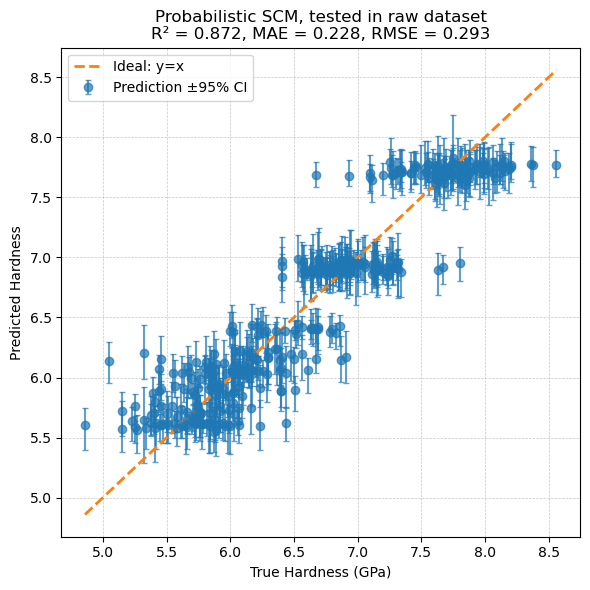

In [14]:
# ============================================================
# Plot: probabilistic SCM prediction vs true hardness
# with uncertainty (95% CI)
# ============================================================

# ----------------------------------------
# Extract values
# ----------------------------------------

y_true = all_results_mc_df["hardness_true"].values * 3 / 1000  # convert MPa to GPa
y_pred = all_results_mc_df["hardness_pred"].values * 3 / 1000  # convert MPa to GPa

y_lower = all_results_mc_df["hardness_lower"].values * 3 / 1000  # convert MPa to GPa
y_upper = all_results_mc_df["hardness_upper"].values * 3 / 1000  # convert MPa to GPa

# error bars
yerr_lower = y_pred - y_lower
yerr_upper = y_upper - y_pred

# ----------------------------------------
# Metrics
# ----------------------------------------

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("Probabilistic SCM performance")
print("R2   =", r2)
print("MAE  =", mae)
print("RMSE =", rmse)

# ----------------------------------------
# Plot
# ----------------------------------------

plt.figure(figsize=(6, 6))

plt.errorbar(
    y_true,
    y_pred,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    alpha=0.7,
    capsize=2,
    label="Prediction ±95% CI"
)

# ideal line
min_val = min(np.min(y_true), np.min(y_lower))
max_val = max(np.max(y_true), np.max(y_upper))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=2,
    label="Ideal: y=x"
)

# labels
plt.xlabel("True Hardness (GPa)")
plt.ylabel("Predicted Hardness")

plt.title(
    f"Probabilistic SCM, tested in raw dataset\n"
    f"R² = {r2:.3f}, "
    f"MAE = {mae:.3f}, "
    f"RMSE = {rmse:.3f}"
)

plt.legend()
plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

# do calculation for causal inference, causal effect 
Causal Effect from x₀ to x₁: CE_X(x₁, x₀) = E[H | do(X = x₁)] - E[H | do(X = x₀)] \
Coupled Causal Effect: CCE(x, y)= E[H | do(x, y)] - E[H | do(x, y_ref)] - E[H | do(x_ref, y)] + E[H | do(x_ref, y_ref)]

In [15]:
# ============================================================
# Causal effect based on expectation
# ============================================================
# ============================================================
# Predict BART mean and uncertainty
# ============================================================

def predict_bart_mean(model_pack, X_new_df):

    X_new = X_new_df[
        model_pack["input_cols"]
    ].values

    y_pred, y_std, y_lower, y_upper = predict_with_uncertainty(
        model=model_pack["model"],
        X=X_new,
        x_scaler=model_pack["x_scaler"],
        y_scaler=model_pack["y_scaler"]
    )

    return y_pred, y_std, y_lower, y_upper

def expected_hardness_do_microstructure(
    Au_at_gb,
    Au_in_grain,
    dislocation_density,
    grain_size
):
    """
    Estimate E[H | do(microstructure values)]
    """

    df_micro = pd.DataFrame({
        "Au_at_gb": [Au_at_gb],
        "Au_in_grain": [Au_in_grain],
        "dislocation_density": [dislocation_density],
        "grain_size": [grain_size]
    })

    # SR strengthening models
    X_hp = df_micro[["grain_size"]].to_numpy(dtype=np.float64)

    X_sss = df_micro[
        ["Au_in_grain", "Au_at_gb"]
    ].to_numpy(dtype=np.float64)

    X_dis = df_micro[
        ["dislocation_density"]
    ].to_numpy(dtype=np.float64)

    SR_HP = model_hp.predict(X_hp)
    SR_SSS = model_sss.predict(X_sss)
    SR_Dis = model_dis.predict(X_dis)

    df_strength = pd.DataFrame({
        "SR_HP": SR_HP.ravel(),
        "SR_SSS": SR_SSS.ravel(),
        "SR_Dis": SR_Dis.ravel()
    })

    # Unified BART gives E[H | do(...)]
    H_mean, H_std, H_low, H_up = predict_bart_mean(
        unified_BART,
        df_strength
    )

    return H_mean[0], H_std[0], H_low[0], H_up[0]

In [16]:
def causal_effect_single(
    var_name,
    x1,
    x0,
    reference_state
):
    """
    CE = E[H | do(X=x1)] - E[H | do(X=x0)]
    """

    state_1 = reference_state.copy()
    state_0 = reference_state.copy()

    state_1[var_name] = x1
    state_0[var_name] = x0

    H1, _, _, _ = expected_hardness_do_microstructure(**state_1)
    H0, _, _, _ = expected_hardness_do_microstructure(**state_0)

    return abs(H1 - H0)

def coupled_causal_effect(
    var1,
    x1,
    x1_ref,
    var2,
    x2,
    x2_ref,
    reference_state
):
    """
    CCE =
    E[H | do(var1=x1, var2=x2)]
    - E[H | do(var1=x1, var2=x2_ref)]
    - E[H | do(var1=x1_ref, var2=x2)]
    + E[H | do(var1=x1_ref, var2=x2_ref)]
    """

    state_11 = reference_state.copy()
    state_10 = reference_state.copy()
    state_01 = reference_state.copy()
    state_00 = reference_state.copy()

    state_11[var1] = x1
    state_11[var2] = x2

    state_10[var1] = x1
    state_10[var2] = x2_ref

    state_01[var1] = x1_ref
    state_01[var2] = x2

    state_00[var1] = x1_ref
    state_00[var2] = x2_ref

    H11, _, _, _ = expected_hardness_do_microstructure(**state_11)
    H10, _, _, _ = expected_hardness_do_microstructure(**state_10)
    H01, _, _, _ = expected_hardness_do_microstructure(**state_01)
    H00, _, _, _ = expected_hardness_do_microstructure(**state_00)

    CCE = abs(H11 - H10 - H01 + H00)

    return CCE

In [17]:
# ============================================================
# Reference state:
# mean values from anneal=0 and punch=0 group
# ============================================================

reference_group = data_all[
    (data_all["anneal"] == 0)
    &
    (data_all["punch"] == 0)
]

reference_state = {
    "Au_at_gb": reference_group["Au_at_gb"].mean(),
    "Au_in_grain": reference_group["Au_in_grain"].mean(),
    "dislocation_density": reference_group["dislocation_density"].mean(),
    "grain_size": reference_group["grain_size"].mean()
}

for i, v in reference_state.items():
    print("Reference state: {i}: {v:.2e}".format(i=i, v=v))
c_ref = reference_state["Au_in_grain"]
rho_ref = reference_state["dislocation_density"]

c1 = data_all["Au_in_grain"].quantile(0.8)
rho1 = data_all["dislocation_density"].quantile(0.8)

CCE = coupled_causal_effect(
    var1="Au_in_grain",
    x1=c1,
    x1_ref=c_ref,
    var2="dislocation_density",
    x2=rho1,
    x2_ref=rho_ref,
    reference_state=reference_state
)

print("Coupled causal effect =", CCE)

Reference state: Au_at_gb: 5.71e+00
Reference state: Au_in_grain: 6.08e+00
Reference state: dislocation_density: 1.13e+14
Reference state: grain_size: 2.86e-08
Coupled causal effect = 0.47644744198851186


In [18]:
def causal_effect_curve_1d(
    var_name,
    reference_state,
    x_grid
):
    x_ref = reference_state[var_name]

    H_ref, _, _, _ = expected_hardness_do_microstructure(
        **reference_state
    )

    effects = []

    for x in x_grid:
        state_do = reference_state.copy()
        state_do[var_name] = x

        H_do, _, _, _ = expected_hardness_do_microstructure(
            **state_do
        )

        effects.append(abs(H_do - H_ref))

    return np.array(effects)

In [19]:
# ============================================================
# Partial intervention SCM:
# intervene selected microstructure variables,
# calculate non-intervened variables by microstructure BART
# ============================================================

def predict_bart_mean(model_pack, X_new_df):
    X_new = X_new_df[model_pack["input_cols"]].values

    y_pred, y_std, y_lower, y_upper = predict_with_uncertainty(
        model=model_pack["model"],
        X=X_new,
        x_scaler=model_pack["x_scaler"],
        y_scaler=model_pack["y_scaler"]
    )

    return y_pred, y_std, y_lower, y_upper


def expected_hardness_partial_do(
    anneal_value,
    punch_value,
    do_values=None
):
    """
    Partial do-operation.

    do_values example:
        {
            "Au_at_gb": 10.0,
            "dislocation_density": 1e14
        }

    Intervened variables are fixed.
    Non-intervened variables are predicted by their BART equations.
    """

    if do_values is None:
        do_values = {}

    df = pd.DataFrame({
        "anneal": [anneal_value],
        "punch": [punch_value]
    })

    # --------------------------------------------------------
    # 1. Au_at_gb
    # --------------------------------------------------------
    if "Au_at_gb" in do_values:
        df["Au_at_gb"] = [do_values["Au_at_gb"]]
    else:
        Au_at_gb, _, _, _ = predict_bart_mean(model_Au_in_GB, df)
        df["Au_at_gb"] = Au_at_gb.ravel()

    # --------------------------------------------------------
    # 2. Au_in_grain
    # --------------------------------------------------------
    if "Au_in_grain" in do_values:
        df["Au_in_grain"] = [do_values["Au_in_grain"]]
    else:
        Au_in_grain, _, _, _ = predict_bart_mean(model_Au_in_grain, df)
        df["Au_in_grain"] = Au_in_grain.ravel()

    # --------------------------------------------------------
    # 3. dislocation_density
    # --------------------------------------------------------
    if "dislocation_density" in do_values:
        df["dislocation_density"] = [do_values["dislocation_density"]]
    else:
        rho, _, _, _ = predict_bart_mean(model_dislocation, df)
        df["dislocation_density"] = rho.ravel()

    # --------------------------------------------------------
    # 4. grain_size
    # --------------------------------------------------------
    if "grain_size" in do_values:
        df["grain_size"] = [do_values["grain_size"]]
    else:
        grain_size, _, _, _ = predict_bart_mean(model_grain_size, df)
        df["grain_size"] = grain_size.ravel()

    # --------------------------------------------------------
    # 5. microstructure -> strengthening
    # --------------------------------------------------------
    X_hp = df[["grain_size"]].to_numpy(dtype=np.float64)

    X_sss = df[
        ["Au_in_grain", "Au_at_gb"]
    ].to_numpy(dtype=np.float64)

    X_dis = df[
        ["dislocation_density"]
    ].to_numpy(dtype=np.float64)

    SR_HP = model_hp.predict(X_hp)
    SR_SSS = model_sss.predict(X_sss)
    SR_Dis = model_dis.predict(X_dis)

    df_strength = pd.DataFrame({
        "SR_HP": SR_HP.ravel(),
        "SR_SSS": SR_SSS.ravel(),
        "SR_Dis": SR_Dis.ravel()
    })

    # --------------------------------------------------------
    # 6. strengthening -> hardness
    # --------------------------------------------------------
    H_mean, H_std, H_low, H_up = predict_bart_mean(
        unified_BART,
        df_strength
    )

    return {
        "hardness_mean": H_mean[0],
        "hardness_std": H_std[0],
        "hardness_lower": H_low[0],
        "hardness_upper": H_up[0],

        "Au_at_gb": df["Au_at_gb"].iloc[0],
        "Au_in_grain": df["Au_in_grain"].iloc[0],
        "dislocation_density": df["dislocation_density"].iloc[0],
        "grain_size": df["grain_size"].iloc[0],

        "SR_HP": SR_HP.ravel()[0],
        "SR_SSS": SR_SSS.ravel()[0],
        "SR_Dis": SR_Dis.ravel()[0]
    }

In [20]:
def coupled_causal_effect_partial_do(
    anneal_ref,
    punch_ref,
    var1,
    x1,
    x1_ref,
    var2,
    x2,
    x2_ref
):
    """
    CCE = H11 - H10 - H01 + H00

    Intervened variables are fixed.
    Other microstructure variables are predicted by BART.
    """

    H11 = expected_hardness_partial_do(
        anneal_value=anneal_ref,
        punch_value=punch_ref,
        do_values={
            var1: x1,
            var2: x2
        }
    )["hardness_mean"]

    H10 = expected_hardness_partial_do(
        anneal_value=anneal_ref,
        punch_value=punch_ref,
        do_values={
            var1: x1,
            var2: x2_ref
        }
    )["hardness_mean"]

    H01 = expected_hardness_partial_do(
        anneal_value=anneal_ref,
        punch_value=punch_ref,
        do_values={
            var1: x1_ref,
            var2: x2
        }
    )["hardness_mean"]

    H00 = expected_hardness_partial_do(
        anneal_value=anneal_ref,
        punch_value=punch_ref,
        do_values={
            var1: x1_ref,
            var2: x2_ref
        }
    )["hardness_mean"]

    CCE_signed = H11 - H10 - H01 + H00
    CCE_strength = abs(CCE_signed)

    return {
        "H11": H11,
        "H10": H10,
        "H01": H01,
        "H00": H00,
        "CCE_signed": CCE_signed,
        "CCE_strength": CCE_strength
    }

In [21]:
# ============================================================
# 1D causal strength curve with partial intervention
# ============================================================

def causal_strength_curve_partial_do(
    var_name,
    x_grid,
    x_ref,
    anneal_ref=0,
    punch_ref=0
):
    records = []

    H_ref = expected_hardness_partial_do(
        anneal_value=anneal_ref,
        punch_value=punch_ref,
        do_values={var_name: x_ref}
    )["hardness_mean"]

    for x in x_grid:

        H_do = expected_hardness_partial_do(
            anneal_value=anneal_ref,
            punch_value=punch_ref,
            do_values={var_name: x}
        )["hardness_mean"]

        CE_signed = H_do - H_ref
        CE_strength = abs(CE_signed)

        records.append({
            var_name: x,
            "x_ref": x_ref,
            "H_do": H_do,
            "H_ref": H_ref,
            "CE_signed": CE_signed,
            "CE_strength": CE_strength
        })

    return pd.DataFrame(records)

In [22]:
anneal_ref = 0
punch_ref = 0

c_ref = reference_state["Au_at_gb"]
rho_ref = reference_state["dislocation_density"]

c1 = data_all["Au_at_gb"].quantile(0.80)
rho1 = data_all["dislocation_density"].quantile(0.80)

out = coupled_causal_effect_partial_do(
    anneal_ref=anneal_ref,
    punch_ref=punch_ref,
    var1="Au_at_gb",
    x1=c1,
    x1_ref=c_ref,
    var2="dislocation_density",
    x2=rho1,
    x2_ref=rho_ref
)

print("Signed CCE =", out["CCE_signed"])
print("Coupled causal strength =", out["CCE_strength"])

Signed CCE = -6.7851089159362346
Coupled causal strength = 6.7851089159362346


In [23]:
def expected_hardness_partial_do_mc(
    anneal_value,
    punch_value,
    do_values=None,
    n_mc=100,
    random_seed=42
):
    if do_values is None:
        do_values = {}

    rng = np.random.default_rng(random_seed)

    # First get microstructure by partial do
    out = expected_hardness_partial_do(
        anneal_value=anneal_value,
        punch_value=punch_value,
        do_values=do_values
    )

    df_strength = pd.DataFrame({
        "SR_HP": [out["SR_HP"]],
        "SR_SSS": [out["SR_SSS"]],
        "SR_Dis": [out["SR_Dis"]]
    })

    # sample unified_BART posterior
    H_post = predict_bart_samples(
        unified_BART,
        df_strength
    )

    H_samples = []

    for _ in range(n_mc):
        j = rng.integers(0, H_post.shape[1])
        H_samples.append(H_post[0, j])

    H_samples = np.array(H_samples)

    return {
        "H_mean": np.mean(H_samples),
        "H_std": np.std(H_samples),
        "H_lower": np.percentile(H_samples, 2.5),
        "H_upper": np.percentile(H_samples, 97.5),
        "H_samples": H_samples,
        **out
    }

In [24]:
def causal_strength_curve_partial_do_mc(
    var_name,
    x_grid,
    x_ref,
    anneal_ref=0,
    punch_ref=0,
    n_mc=100,
    random_seed=42
):
    records = []

    ref_out = expected_hardness_partial_do_mc(
        anneal_value=anneal_ref,
        punch_value=punch_ref,
        do_values={var_name: x_ref},
        n_mc=n_mc,
        random_seed=random_seed
    )

    H_ref_samples = ref_out["H_samples"]

    for i, x in enumerate(x_grid):

        do_out = expected_hardness_partial_do_mc(
            anneal_value=anneal_ref,
            punch_value=punch_ref,
            do_values={var_name: x},
            n_mc=n_mc,
            random_seed=random_seed + i + 1
        )

        H_do_samples = do_out["H_samples"]

        delta_samples = H_do_samples - H_ref_samples

        CE_signed_mean = np.mean(delta_samples)
        CE_strength_samples = np.abs(delta_samples)

        records.append({
            var_name: x,
            "x_ref": x_ref,

            "CE_signed_mean": CE_signed_mean,
            "CE_signed_std": np.std(delta_samples),
            "CE_signed_lower": np.percentile(delta_samples, 2.5),
            "CE_signed_upper": np.percentile(delta_samples, 97.5),

            "CE_strength_mean": np.mean(CE_strength_samples),
            "CE_strength_std": np.std(CE_strength_samples),
            "CE_strength_lower": np.percentile(CE_strength_samples, 2.5),
            "CE_strength_upper": np.percentile(CE_strength_samples, 97.5),

            "P_positive_effect": np.mean(delta_samples > 0),
            "P_negative_effect": np.mean(delta_samples < 0)
        })

    return pd.DataFrame(records)

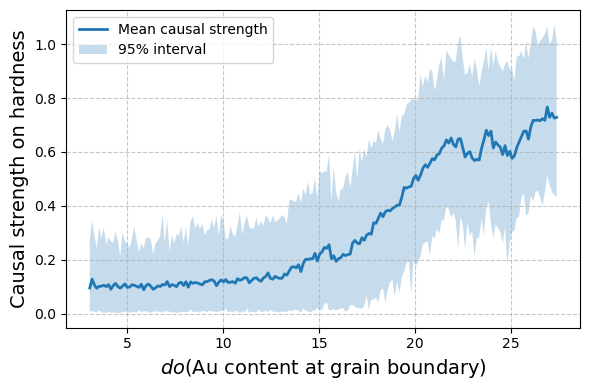

In [25]:
var_name = "Au_at_gb"
x_ref = reference_state[var_name]

x_grid = np.linspace(
    data_all[var_name].quantile(0.05),
    data_all[var_name].quantile(0.95),
    200
)

curve_df = causal_strength_curve_partial_do_mc(
    var_name=var_name,
    x_grid=x_grid,
    x_ref=x_ref,
    anneal_ref=0,
    punch_ref=0,
    n_mc=100,
    random_seed=42
)

plt.figure(figsize=(6, 4))

plt.plot(
    curve_df[var_name],
    curve_df["CE_strength_mean"]*3/1000, # convert MPa to GPa
    linewidth=2,
    label="Mean causal strength"
)

plt.fill_between(
    curve_df[var_name],
    curve_df["CE_strength_lower"] * 3 / 1000, # convert MPa to GPa
    curve_df["CE_strength_upper"] * 3 / 1000, # convert MPa to GPa
    alpha=0.25,
    label="95% interval"
)


plt.xlabel(r"$\it{do}$(Au content at grain boundary)", fontsize=14)
plt.ylabel("Causal strength on hardness", fontsize=14)


plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

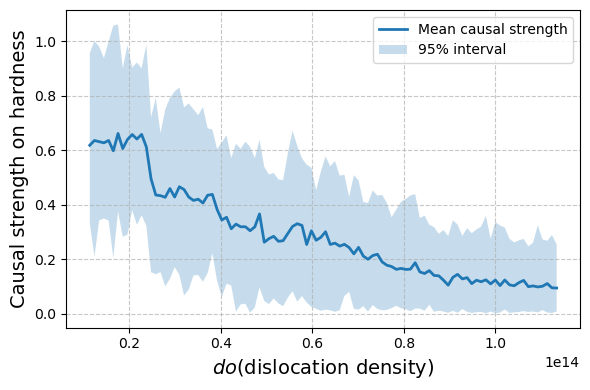

In [26]:
var_name = "dislocation_density"
x_ref = reference_state[var_name]

x_grid = np.linspace(
    data_all[var_name].quantile(0.05),
    data_all[var_name].quantile(0.95),
    100
)

curve_df = causal_strength_curve_partial_do_mc(
    var_name=var_name,
    x_grid=x_grid,
    x_ref=x_ref,
    anneal_ref=0,
    punch_ref=0,
    n_mc=50,
    random_seed=42
)

plt.figure(figsize=(6, 4))

plt.plot(
    curve_df[var_name],
    curve_df["CE_strength_mean"]*3/1000, # convert MPa to GPa
    linewidth=2,
    label="Mean causal strength"
)

plt.fill_between(
    curve_df[var_name],
    curve_df["CE_strength_lower"] * 3 / 1000, # convert MPa to GPa
    curve_df["CE_strength_upper"] * 3 / 1000, # convert MPa to GPa
    alpha=0.25,
    label="95% interval"
)

plt.xlabel(r"$\it{do}$(dislocation density)", fontsize=14)
plt.ylabel("Causal strength on hardness", fontsize=14)


plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Intervene on Au_at_gb and dislocation density

In [27]:
# ============================================================
# Coupled causal strength map with uncertainty
# do(Au_at_gb, dislocation_density)
# Non-intervened microstructure variables are predicted by BART
# ============================================================

def coupled_causal_effect_partial_do_mc(
    anneal_ref,
    punch_ref,
    var1,
    x1,
    x1_ref,
    var2,
    x2,
    x2_ref,
    n_mc=20,
    random_seed=42
):
    """
    CCE = H11 - H10 - H01 + H00

    Causal strength = abs(CCE)

    Uses partial do-operation:
    intervened variables are fixed;
    non-intervened microstructure variables are still predicted by BART.
    """

    out11 = expected_hardness_partial_do_mc(
        anneal_value=anneal_ref,
        punch_value=punch_ref,
        do_values={var1: x1, var2: x2},
        n_mc=n_mc,
        random_seed=random_seed
    )

    out10 = expected_hardness_partial_do_mc(
        anneal_value=anneal_ref,
        punch_value=punch_ref,
        do_values={var1: x1, var2: x2_ref},
        n_mc=n_mc,
        random_seed=random_seed + 10000
    )

    out01 = expected_hardness_partial_do_mc(
        anneal_value=anneal_ref,
        punch_value=punch_ref,
        do_values={var1: x1_ref, var2: x2},
        n_mc=n_mc,
        random_seed=random_seed + 20000
    )

    out00 = expected_hardness_partial_do_mc(
        anneal_value=anneal_ref,
        punch_value=punch_ref,
        do_values={var1: x1_ref, var2: x2_ref},
        n_mc=n_mc,
        random_seed=random_seed + 30000
    )

    H11 = out11["H_samples"]
    H10 = out10["H_samples"]
    H01 = out01["H_samples"]
    H00 = out00["H_samples"]

    cce_samples = H11 - H10 - H01 + H00
    strength_samples = np.abs(cce_samples)

    return {
        "CCE_signed_mean": np.mean(cce_samples),
        "CCE_signed_std": np.std(cce_samples),
        "CCE_signed_lower": np.percentile(cce_samples, 16),
        "CCE_signed_upper": np.percentile(cce_samples, 84),

        "CCE_strength_mean": np.mean(strength_samples),
        "CCE_strength_std": np.std(strength_samples),
        "CCE_strength_lower": np.percentile(strength_samples, 16),
        "CCE_strength_upper": np.percentile(strength_samples, 84),

        "P_synergy": np.mean(cce_samples > 0),
        "P_antagonism": np.mean(cce_samples < 0),

        # store BART-generated microstructure for plotting
        "Au_at_gb": out11["Au_at_gb"],   
        "Au_in_grain": out11["Au_in_grain"],
        "dislocation_density": out11["dislocation_density"],
        "grain_size": out11["grain_size"],
    }

In [28]:
# ============================================================
# Build 2D causal strength map
# ============================================================

def coupled_causal_strength_map_partial_do_mc(
    c_grid,
    rho_grid,
    c_ref,
    rho_ref,
    anneal_ref=0,
    punch_ref=0,
    n_mc=20,
    random_seed=42
):
    strength_mean_map = np.zeros((len(rho_grid), len(c_grid)))
    strength_lower_map = np.zeros((len(rho_grid), len(c_grid)))
    strength_upper_map = np.zeros((len(rho_grid), len(c_grid)))
    strength_std_map = np.zeros((len(rho_grid), len(c_grid)))
    grain_size_map = np.zeros((len(rho_grid), len(c_grid)))
    Au_in_grain_map = np.zeros((len(rho_grid), len(c_grid)))

    signed_mean_map = np.zeros((len(rho_grid), len(c_grid)))
    p_synergy_map = np.zeros((len(rho_grid), len(c_grid)))

    for i, rho in enumerate(rho_grid):
        for j, c in enumerate(c_grid):

            out = coupled_causal_effect_partial_do_mc(
                anneal_ref=anneal_ref,
                punch_ref=punch_ref,

                var1="Au_at_gb",
                x1=c,
                x1_ref=c_ref,

                var2="dislocation_density",
                x2=rho,
                x2_ref=rho_ref,

                n_mc=n_mc,
                random_seed=random_seed + i * 1000 + j
                
            )

            strength_mean_map[i, j] = out["CCE_strength_mean"]
            strength_lower_map[i, j] = out["CCE_strength_lower"]
            strength_upper_map[i, j] = out["CCE_strength_upper"]
            strength_std_map[i, j] = out["CCE_strength_std"]
            grain_size_map[i, j] = out["grain_size"]
            Au_in_grain_map[i, j] = out["Au_in_grain"]

            signed_mean_map[i, j] = out["CCE_signed_mean"]
            p_synergy_map[i, j] = out["P_synergy"]

    return {
        "strength_mean": strength_mean_map,
        "strength_lower": strength_lower_map,
        "strength_upper": strength_upper_map,
        "strength_std": strength_std_map,
        "signed_mean": signed_mean_map,
        "p_synergy": p_synergy_map,
        "grain_size": grain_size_map,
        "Au_in_grain": Au_in_grain_map
    }

In [29]:
# ============================================================
# Intervention grid
# x-axis: do(Au_at_gb)
# y-axis: do(dislocation_density)
# ============================================================

c_grid = np.linspace(
    data_all["Au_at_gb"].quantile(0.05),
    data_all["Au_at_gb"].quantile(0.95),
    20
)

rho_grid = np.linspace(
    data_all["dislocation_density"].quantile(0.05),
    data_all["dislocation_density"].quantile(0.95),
    20
)

anneal_ref = 0
punch_ref = 0

c_ref = reference_state["Au_at_gb"]
rho_ref = reference_state["dislocation_density"]

In [30]:
maps = coupled_causal_strength_map_partial_do_mc(
    c_grid=c_grid,
    rho_grid=rho_grid,
    c_ref=c_ref,
    rho_ref=rho_ref,
    anneal_ref=anneal_ref,
    punch_ref=punch_ref,
    n_mc=50,
    random_seed=42
)

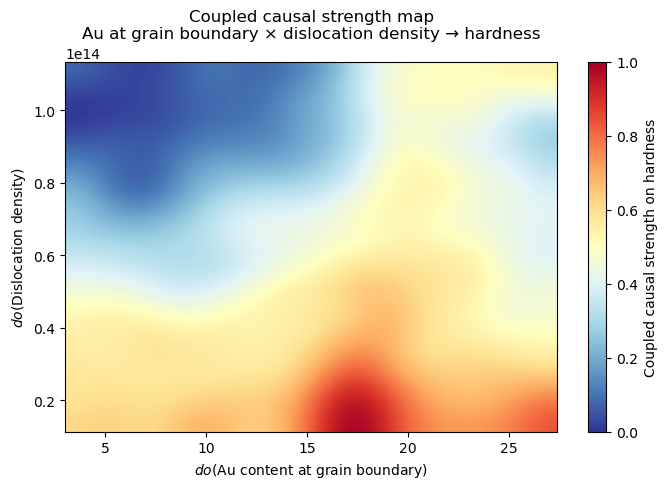

In [34]:

# ============================================================
# Prepare maps
# ============================================================

strength = maps["strength_mean"]

# Smooth only for visualization
strength_smooth = gaussian_filter(strength, sigma=1.2)

# Normalize the smoothed causal-strength map to [0, 1]
strength_min = np.nanmin(strength_smooth)
strength_max = np.nanmax(strength_smooth)

if np.isclose(strength_max, strength_min):
    raise ValueError(
        "The strength map is constant and cannot be normalized."
    )

strength_normalized = (
    strength_smooth - strength_min
) / (
    strength_max - strength_min
)

# Grain-size map in nm
grain_size_map = maps["grain_size"] * 1e9
grain_size_map_smooth = gaussian_filter(
    grain_size_map,
    sigma=1
)


# ============================================================
# Optional boundary index
# ============================================================

gx, gy = np.gradient(strength_normalized)

boundary_index = gaussian_filter(
    np.sqrt(gx**2 + gy**2),
    sigma=2
)


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7, 5))

im = plt.imshow(
    strength_normalized,
    origin="lower",
    aspect="auto",
    extent=[
        c_grid.min(),
        c_grid.max(),
        rho_grid.min(),
        rho_grid.max()
    ],
    interpolation="bicubic",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=1
)

# Grain-size contours
contours = plt.contour(
    c_grid,
    rho_grid,
    grain_size_map_smooth,
    colors="white",
    linewidths=1.2,
    levels=10,
    linestyles="--",
    alpha=0
)

plt.clabel(
    contours,
    inline=True,
    fontsize=14,
    fmt="%.0f"
)

cbar = plt.colorbar(im)
cbar.set_label("Coupled causal strength on hardness")

plt.xlabel(r"$\it{do}$(Au content at grain boundary)")
plt.ylabel(r"$\it{do}$(Dislocation density)")

plt.title(
    "Coupled causal strength map\n"
    "Au at grain boundary × dislocation density → hardness"
)

plt.tight_layout()
plt.show()